# <center>CO2 LSTM Forecasting</center>

> Authors:
> - D11202805 - Ian Joseph Chandra
> - M11002818 - Wilfrid Azariah

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input
from datetime import timedelta

# # Load data
df = pd.read_csv('./data/emissions.csv')

df

2024-06-06 15:22:14.005025: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


,year,state-name,sector-name,fuel-name,value
0,1970,Alabama,Industrial carbon dioxide emissions,Coal,26.721507
1,1970,Alabama,Industrial carbon dioxide emissions,Petroleum,3.577779
2,1970,Alabama,Industrial carbon dioxide emissions,Natural Gas,8.944097
3,1970,Alabama,Industrial carbon dioxide emissions,All Fuels,39.243383
4,1970,Alabama,Total carbon dioxide emissions from all sectors,All Fuels,102.646851
...,...,...,...,...,...
59896,2021,Wyoming,Commercial carbon dioxide emissions,Coal,0.012374
59897,2021,Wyoming,Residential carbon dioxide emissions,All Fuels,0.937989
59898,2021,Wyoming,Residential carbon dioxide emissions,Natural Gas,0.717777
59899,2021,Wyoming,Residential carbon dioxide emissions,Petroleum,0.220212


# Step 2: Data Preprocessing

### 2.1 Data Cleaning

In [3]:
# Remove "-name" from column names
df.columns = df.columns.str.replace('-name', '')

# Rename value column to "emission"
df = df.rename(columns={'value': 'emission'})

# Remove "carbon dioxide emissions" from 'sector' column
df['sector'] = df['sector'].str.replace(' carbon dioxide emissions', '')

df

,year,state,sector,fuel,emission
0,1970,Alabama,Industrial,Coal,26.721507
1,1970,Alabama,Industrial,Petroleum,3.577779
2,1970,Alabama,Industrial,Natural Gas,8.944097
3,1970,Alabama,Industrial,All Fuels,39.243383
4,1970,Alabama,Total from all sectors,All Fuels,102.646851
...,...,...,...,...,...
59896,2021,Wyoming,Commercial,Coal,0.012374
59897,2021,Wyoming,Residential,All Fuels,0.937989
59898,2021,Wyoming,Residential,Natural Gas,0.717777
59899,2021,Wyoming,Residential,Petroleum,0.220212


### 2.2 Data Classification

In [4]:
# Exclude 'state' column & group by 'year', 'sector', 'fuel'
df = df.drop('state', axis=1)

state_excluded = df.groupby(['year', 'sector', 'fuel'], as_index=False)['emission'].sum()
state_excluded

,year,sector,fuel,emission
0,1970,Commercial,All Fuels,524.952430
1,1970,Commercial,Coal,31.306261
2,1970,Commercial,Natural Gas,260.289232
3,1970,Commercial,Petroleum,233.356940
4,1970,Electric Power,All Fuels,2122.880364
...,...,...,...,...
1185,2021,Total from all sectors,Natural Gas,3309.710677
1186,2021,Total from all sectors,Petroleum,4495.529265
1187,2021,Transportation,All Fuels,3629.705997
1188,2021,Transportation,Natural Gas,129.829709


In [5]:
state_excluded

,year,sector,fuel,emission
0,1970,Commercial,All Fuels,524.952430
1,1970,Commercial,Coal,31.306261
2,1970,Commercial,Natural Gas,260.289232
3,1970,Commercial,Petroleum,233.356940
4,1970,Electric Power,All Fuels,2122.880364
...,...,...,...,...
1185,2021,Total from all sectors,Natural Gas,3309.710677
1186,2021,Total from all sectors,Petroleum,4495.529265
1187,2021,Transportation,All Fuels,3629.705997
1188,2021,Transportation,Natural Gas,129.829709


In [6]:
# Remove data where sector column contains "Total" but fuel column not contains "All", vice versa
dataset = state_excluded[~((state_excluded['sector'].str.contains('Total')) & (~state_excluded['fuel'].str.contains('All')))]

# Drop the data where fuel column contains "All" but the sector column does not contain "Total"
dataset = dataset[~((dataset['fuel'].str.contains('All')) & (~dataset['sector'].str.contains('Total')))]
dataset

,year,sector,fuel,emission
1,1970,Commercial,Coal,31.306261
2,1970,Commercial,Natural Gas,260.289232
3,1970,Commercial,Petroleum,233.356940
5,1970,Electric Power,Coal,1374.959395
6,1970,Electric Power,Natural Gas,429.208459
...,...,...,...,...
1181,2021,Residential,Natural Gas,520.017628
1182,2021,Residential,Petroleum,132.467958
1183,2021,Total from all sectors,All Fuels,9822.454659
1188,2021,Transportation,Natural Gas,129.829709


In [7]:
# Group by fuel
fuel_group = state_excluded.groupby(['year', 'fuel'], as_index=False)['emission'].sum()

# Create a dictionary where each key is a type of fuel and each value is a DataFrame containing the data for that type of fuel
fuels = {fuel: fuel_group[fuel_group['fuel'] == fuel] for fuel in fuel_group['fuel'].unique()}

# Drop the 'fuel' column from each DataFrame in the dictionary
for fuel in fuels:
    fuels[fuel] = fuels[fuel].drop(columns='fuel')

fuels['names'] = fuel_group['fuel'].unique()

fuels

{'All Fuels':      year      emission
 0    1970  17014.127120
 4    1971  17194.781770
 8    1972  18073.655241
 12   1973  18860.727157
 16   1974  18175.305372
 20   1975  17679.114086
 24   1976  18755.877587
 28   1977  19309.774423
 32   1978  19475.066319
 36   1979  19706.707301
 40   1980  19011.190499
 44   1981  18521.969164
 48   1982  17552.978918
 52   1983  17501.919941
 56   1984  18402.032232
 60   1985  18419.925574
 64   1986  18430.785393
 68   1987  19033.562825
 72   1988  19948.256274
 76   1989  20250.864725
 80   1990  20092.298569
 84   1991  19889.216334
 88   1992  20256.731634
 92   1993  20666.893787
 96   1994  20966.102185
 100  1995  21225.034683
 104  1996  22016.886931
 108  1997  22307.457496
 112  1998  22451.999508
 116  1999  22707.771792
 120  2000  23465.144872
 124  2001  23026.453602
 128  2002  23178.949578
 132  2003  23463.896237
 136  2004  23858.321175
 140  2005  23959.817719
 144  2006  23628.224594
 148  2007  23989.204672
 152  2008  

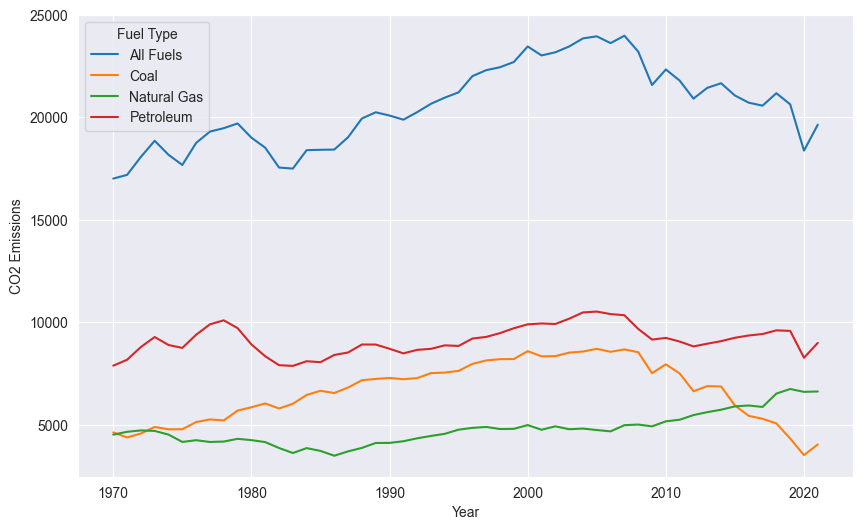

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=fuel_group, x='year', y='emission', hue='fuel')
# plt.title('Yearly CO2 Emissions by Fuel Type')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions')
plt.legend(title='Fuel Type')
plt.grid(True)
plt.show()


In [9]:
# Group by sector
sector_group = state_excluded.groupby(['year', 'sector'], as_index=False)['emission'].sum()

# Create a dictionary where each key is a type of sector and each value is a DataFrame containing the data for that type of sector
sectors = {sector: sector_group[sector_group['sector'] == sector] for sector in sector_group['sector'].unique()}

# Drop the 'fuel' column from each DataFrame in the dictionary
for sector in sectors:
    sectors[sector] = sectors[sector].drop(columns='sector')

sectors['names'] = sector_group['sector'].unique()

sectors

{'Commercial':      year     emission
 0    1970  1049.904863
 6    1971  1067.408942
 12   1972  1086.072463
 18   1973  1096.304213
 24   1974  1048.944410
 30   1975   991.684408
 36   1976  1070.573386
 42   1977  1051.434945
 48   1978  1059.618509
 54   1979  1059.988302
 60   1980   997.525032
 66   1981   928.025500
 72   1982   930.156936
 78   1983   934.719001
 84   1984   974.344561
 90   1985   899.738922
 96   1986   897.193044
 102  1987   908.749829
 108  1988   953.042963
 114  1989   940.962093
 120  1990   908.167424
 126  1991   911.008010
 132  1992   915.663928
 138  1993   906.901870
 144  1994   916.032559
 150  1995   929.068852
 156  1996   964.273785
 162  1997   964.848132
 168  1998   897.207276
 174  1999   905.790225
 180  2000   958.386099
 186  2001   921.364713
 192  2002   926.832241
 198  2003   969.151311
 204  2004   954.872458
 210  2005   911.177922
 216  2006   832.775718
 222  2007   869.775420
 228  2008   905.657500
 234  2009   896.110721
 2

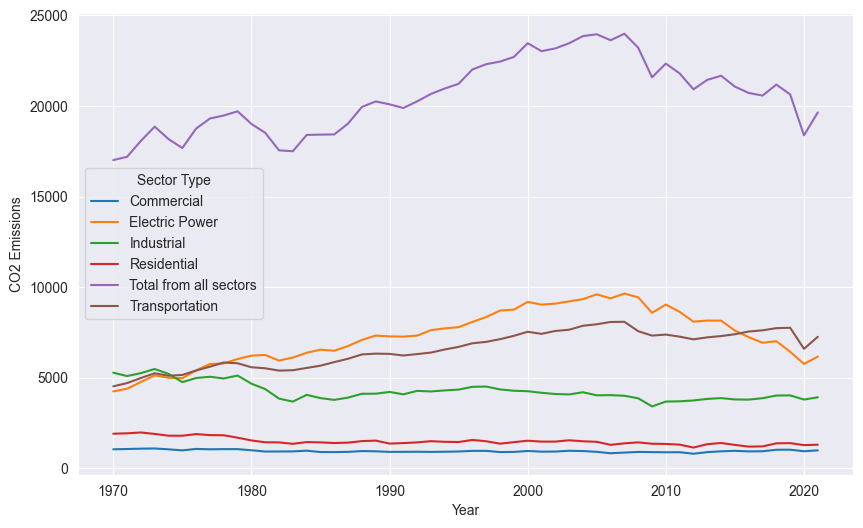

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=sector_group, x='year', y='emission', hue='sector')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions')
plt.legend(title='Sector Type')
plt.grid(True)
plt.show()

### 2.4 "emission" Data Scaling

In [ ]:
scaler = MinMaxScaler()
fuels["Coal"].loc[:, 'emission'] = scaler.fit_transform(fuels["Coal"]['emission'].values.reshape(-1, 1))
fuels["Natural Gas"].loc[:, 'emission'] = scaler.fit_transform(fuels["Natural Gas"]['emission'].values.reshape(-1, 1))
fuels["Petroleum"].loc[:, 'emission'] = scaler.fit_transform(fuels["Petroleum"]['emission'].values.reshape(-1, 1))


fuels

In [ ]:
sectors["Commercial"].loc[:, 'emission'] = scaler.fit_transform(sectors["Commercial"]['emission'].values.reshape(-1, 1))
sectors["Electric Power"].loc[:, 'emission'] = scaler.fit_transform(
    sectors["Electric Power"]['emission'].values.reshape(-1, 1))
sectors["Industrial"].loc[:, 'emission'] = scaler.fit_transform(sectors["Industrial"]['emission'].values.reshape(-1, 1))
sectors["Residential"].loc[:, 'emission'] = scaler.fit_transform(
    sectors["Residential"]['emission'].values.reshape(-1, 1))
sectors["Transportation"].loc[:, 'emission'] = scaler.fit_transform(
    sectors["Transportation"]['emission'].values.reshape(-1, 1))

sectors

### 2.5 Train & Test Dataset Split

In [ ]:
fuels_train = {
    "Coal": fuels["Coal"][fuels["Coal"]["year"] <= 2015],
    "Natural Gas": fuels["Natural Gas"][fuels["Natural Gas"]["year"] <= 2015],
    "Petroleum": fuels["Petroleum"][fuels["Petroleum"]["year"] <= 2015]
}

fuels_train

In [ ]:
fuels_test = {
    "Coal": fuels["Coal"][fuels["Coal"]["year"] > 2015],
    "Natural Gas": fuels["Natural Gas"][fuels["Natural Gas"]["year"] > 2015],
    "Petroleum": fuels["Petroleum"][fuels["Petroleum"]["year"] > 2015]
}

fuels_test

In [ ]:
sectors['names']

In [ ]:
sectors_test = {
    "Commercial": sectors["Commercial"][sectors["Commercial"]["year"] > 2015],
    "Electric Power": sectors["Electric Power"][sectors["Electric Power"]["year"] > 2015],
    "Industrial": sectors["Industrial"][sectors["Industrial"]["year"] > 2015],
    "Residential": sectors["Residential"][sectors["Residential"]["year"] > 2015],
    "Transportation": sectors["Transportation"][sectors["Transportation"]["year"] > 2015]
}

sectors_test

## Step 3: LSTM Dataset Preparation

In [ ]:
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)


lookback = 3  # Adjust this based on your data and model performance

In [ ]:
fuel_X_train_dataset = {}
fuel_y_train_dataset = {}

for name in fuels["names"]:
    fuel_X_train_dataset[name], fuel_y_train_dataset[name] = create_dataset(fuels_train[name][['emission']].values,
                                                                            lookback)

fuel_X_train_dataset

In [ ]:
fuel_y_train_dataset

In [ ]:
fuel_X_test_dataset = {}
fuel_y_test_dataset = {}

for name in fuels["names"]:
    fuel_X_test_dataset[name], fuel_y_test_dataset[name] = create_dataset(fuels_test[name][['emission']].values,
                                                                          lookback)

fuel_X_test_dataset

In [ ]:
fuel_y_test_dataset

## Step 4: LSTM Model

### 4.1 Fuel LSTM Model

#### 4.1.1 Create Models

In [ ]:
fuel_models = {
    "Coal": Sequential(),
    "Natural Gas": Sequential(),
    "Petroleum": Sequential()
}

for key in fuel_models:
    print(key)
    fuel_models[key].add(Input(shape=(lookback, 1)))
    fuel_models[key].add(LSTM(units=50, return_sequences=True))
    fuel_models[key].add(Dropout(0.2))
    fuel_models[key].add(LSTM(units=50, return_sequences=True))
    fuel_models[key].add(Dropout(0.2))
    fuel_models[key].add(LSTM(units=50))
    fuel_models[key].add(Dropout(0.2))
    fuel_models[key].add(Dense(units=1))

    fuel_models[key].compile(optimizer='adam', loss='mean_squared_error')
    fuel_models[key].summary()



#### 4.1.2 Train Models

In [ ]:
# Train the models
for name in fuel_models:
    fuel_models[name].fit(fuel_X_train_dataset[name], fuel_y_train_dataset[name], epochs=50, batch_size=32)

#### 4.1.3 Test Models

In [ ]:
# Prepare input data for prediction
fuel_X_test_dataset_reshaped = {}
for name in fuel_X_test_dataset:
    fuel_X_test_dataset_reshaped[name] = np.reshape(fuel_X_test_dataset[name], (
    fuel_X_test_dataset[name].shape[0], fuel_X_test_dataset[name].shape[1], 1))

# Predict the test data
fuel_predictions = {}
for name in fuel_models:
    fuel_predictions[name] = fuel_models[name].predict(fuel_X_test_dataset_reshaped[name])
    fuel_predictions[name] = scaler.inverse_transform(fuel_predictions[name]).flatten()

fuel_predictions

In [ ]:
# Calculate the RMSE for each fuel type
from sklearn.metrics import mean_squared_error

fuel_rmse = {}
for name in fuel_predictions:
    fuel_rmse[name] = np.sqrt(mean_squared_error(fuels_test[name].iloc[lookback:, 0], fuel_predictions[name]))

fuel_rmse

In [ ]:
# Calculate the MAE for each fuel type
from sklearn.metrics import mean_absolute_error

fuel_mae = {}
for name in fuel_predictions:
    fuel_mae[name] = mean_absolute_error(fuels_test[name].iloc[lookback:, 0], fuel_predictions[name])

fuel_mae


In [ ]:
# Combine the predictions into actual fuels & year
fuel_predictions_combined = pd.DataFrame()
for name in fuel_predictions:
    fuel_predictions_combined = pd.concat(
        [fuel_predictions_combined, pd.DataFrame(fuel_predictions[name], columns=[name])], axis=1)

fuel_predictions_combined['year'] = fuels_test['Coal'].iloc[lookback:, 1].values
fuel_predictions_combined = fuel_predictions_combined.set_index('year')

fuel_predictions_combined

In [ ]:
# Plot the predictions along with the actual data for all fuels & years
plt.figure(figsize=(10, 6))
for name in fuel_predictions:
    plt.plot(fuels_test[name].iloc[lookback:, 0], label=f'{name} Actual')
    # plt.plot(fuel_predictions[name], label=f'{name} Predicted')
plt.title('CO2 Emissions Prediction by Fuel Type')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions')
plt.legend(title='Fuel Type')
plt.grid(True)
plt.show()


### 4.2 Sector LSTM Model